In [ ]:
# Import functions from preprocessing.py
import sys
import os
import torch


# Add the path to the src directory
sys.path.append(os.path.abspath(os.path.join('..', 'data')))
from generation_torch import generate_location_and_partitions, generate_data
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
input_dim = 1

B = 49  # Number of regions
sigmasq_true = 5
phi_true = 4
tausq_true = 0.25
nu_true=0.5
beta_true = 8
# Data generation
for n_i in [4, 6, 8, 10, 20]:
    N = B * n_i
    torch.manual_seed(5556)  # Set a seed for reproducibility
    perm_x = torch.randperm(n_i)
    perm_s = torch.randperm(n_i)
    # Convert perm_s into a permutation matrix
    perm_matrix_s = torch.zeros(n_i, n_i, dtype=torch.float32, device=device)
    perm_matrix_s[torch.arange(n_i), perm_s] = 1

    # Convert perm_x into a permutation matrix
    perm_matrix_x = torch.zeros(n_i, n_i, dtype=torch.float32, device=device)
    perm_matrix_x[torch.arange(n_i), perm_x] = 1
    for seed_generate in range(1, 101):
        # Generate data
        torch.manual_seed(1)
        s, region_assignments = generate_location_and_partitions(B, n_i)
        x = torch.rand(N, 1)
        torch.manual_seed(seed_generate)
        y, w, e = generate_data(s, x, sigmasq_true, phi_true, beta_true, tausq_true, seed=seed_generate)
        # Jumbled data generation
        y = torch.tensor(y, dtype=torch.float32, device=device)
        x = torch.tensor(x, dtype=torch.float32, device=device)
        w = torch.tensor(w, dtype=torch.float32, device=device)
        e = torch.tensor(e, dtype=torch.float32, device=device)
        s = torch.tensor(s, dtype=torch.float32, device=device)
        region_assignments = torch.tensor(region_assignments, dtype=torch.int64, device=device)  # Region indices as integers
        unique_regions = torch.unique(region_assignments)

        # Jumble x and s within regions
        x_jumbled_within_regions = torch.zeros_like(x)
        s_jumbled_within_regions = torch.zeros_like(s)

        for i, region in enumerate(unique_regions):
            # Get indices for the current region
            indices = torch.where(region_assignments == region)[0]
            
            # Assign the shuffled values back
            x_jumbled_within_regions[indices] = x[indices[perm_x]]
            s_jumbled_within_regions[indices] = s[indices[perm_s]]

        # Create the directory structure if it doesn't exist
        output_dir = os.path.join('..', 'data', f"B_{B}_n_{n_i}")
        os.makedirs(output_dir, exist_ok=True)

        # Save the tensors to a file
        output_file = os.path.join(output_dir, f"data_seed_{seed_generate}.pt")
        torch.save({
            'y': y,
            'region_assignments': region_assignments,
            'x': x,
            'w': w,
            'e': e,
            's': s,
            'x_jumbled_within_regions': x_jumbled_within_regions,
            's_jumbled_within_regions': s_jumbled_within_regions,
            'perm_matrix_x': perm_matrix_x,
            'perm_matrix_s': perm_matrix_s,
            'sigmasq_true': sigmasq_true,
            'phi_true': phi_true,
            'beta_true': beta_true,
            'nu_true': nu_true,
            'tausq_true': tausq_true
        }, output_file)

        print(f"Data saved to {output_file}")


/Users/debangandey/Documents/GitHub/SpatialReg-Unlinked/data/generation_torch.py:73: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  w = torch.tensor(torch.distributions.MultivariateNormal(torch.zeros(N), K).sample())
/var/folders/w7/jxz2zn316391355qstwl03940000gn/T/ipykernel_33910/1388712766.py:40: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y = torch.tensor(y, dtype=torch.float32, device=device)
/var/folders/w7/jxz2zn316391355qstwl03940000gn/T/ipykernel_33910/1388712766.py:41: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x = torch.tens

Data saved to ../data/B_100_n_4/data_seed_1.pt
Data saved to ../data/B_100_n_4/data_seed_2.pt
Data saved to ../data/B_100_n_4/data_seed_3.pt
Data saved to ../data/B_100_n_4/data_seed_4.pt
Data saved to ../data/B_100_n_4/data_seed_5.pt
Data saved to ../data/B_100_n_4/data_seed_6.pt
Data saved to ../data/B_100_n_4/data_seed_7.pt
Data saved to ../data/B_100_n_4/data_seed_8.pt
Data saved to ../data/B_100_n_4/data_seed_9.pt
Data saved to ../data/B_100_n_4/data_seed_10.pt
Data saved to ../data/B_100_n_4/data_seed_11.pt
Data saved to ../data/B_100_n_4/data_seed_12.pt
Data saved to ../data/B_100_n_4/data_seed_13.pt
Data saved to ../data/B_100_n_4/data_seed_14.pt
Data saved to ../data/B_100_n_4/data_seed_15.pt
Data saved to ../data/B_100_n_4/data_seed_16.pt
Data saved to ../data/B_100_n_4/data_seed_17.pt
Data saved to ../data/B_100_n_4/data_seed_18.pt
Data saved to ../data/B_100_n_4/data_seed_19.pt
Data saved to ../data/B_100_n_4/data_seed_20.pt
Data saved to ../data/B_100_n_4/data_seed_21.pt
D

In [56]:
import torch

phi_values = torch.linspace(0.5, 10, steps=20, device=device)
traces = []

for phi in phi_values:
    # Compute the distance matrix
    Dist = torch.cdist(s_jumbled_within_regions, s_jumbled_within_regions, p=2)
    
    # Compute the matrix exp(-phi * Dist)
    exp_matrix = torch.exp(-phi * Dist)
    exp_matrix = (exp_matrix + exp_matrix.T)/2  # Make it symmetric
    
    # Compute the inverse of the matrix
    #inv_matrix = torch.linalg.pinv(exp_matrix)
    #inv_matrix = torch.linalg.lstsq(exp_matrix, torch.eye(exp_matrix.size(0), device=device), driver='gelsy')[0]
    inv_matrix = torch.linalg.pinv(exp_matrix, rcond=1e-4)
    # Check if the inverse matrix is symmetric
    is_symmetric = torch.allclose(inv_matrix, inv_matrix.T, atol=1e-6)

    # Check if the inverse matrix is positive definite
    eigenvalues = torch.linalg.eigvalsh(inv_matrix)
    is_positive_definite = torch.all(eigenvalues > 0)

    print(f"Symmetric: {is_symmetric}, Positive Definite: {is_positive_definite}")
    
    # Compute the trace of the inverse matrix
    trace_value = torch.trace(inv_matrix)
    traces.append(trace_value.item())

# Print the traces for each phi value
for phi, trace in zip(phi_values, traces):
    print(f"phi: {phi:.1f}, trace: {trace:.4f}")

Symmetric: False, Positive Definite: False
Symmetric: False, Positive Definite: False
Symmetric: False, Positive Definite: False
Symmetric: False, Positive Definite: False
Symmetric: False, Positive Definite: False
Symmetric: False, Positive Definite: False
Symmetric: False, Positive Definite: False
Symmetric: False, Positive Definite: False
Symmetric: False, Positive Definite: False
Symmetric: False, Positive Definite: False
Symmetric: False, Positive Definite: False
Symmetric: False, Positive Definite: True
Symmetric: False, Positive Definite: True
Symmetric: False, Positive Definite: True
Symmetric: False, Positive Definite: True
Symmetric: False, Positive Definite: True
Symmetric: False, Positive Definite: True
Symmetric: False, Positive Definite: True
Symmetric: False, Positive Definite: True
Symmetric: False, Positive Definite: True
phi: 0.5, trace: 716.6909
phi: 1.0, trace: 1882.3247
phi: 1.5, trace: 3830.7998
phi: 2.0, trace: 7003.0205
phi: 2.5, trace: 9481.9883
phi: 3.0, trace

In [55]:

torch.linalg.lstsq(exp_matrix, torch.eye(exp_matrix.size(0), device=device), driver='gelsy').solution

tensor([[ 1.9902e+00, -1.1064e+00, -7.5412e-02,  ...,  3.9051e-06,
          6.2590e-08,  1.8523e-07],
        [-1.1064e+00,  5.5831e+00, -2.3183e+00,  ..., -7.1995e-06,
          1.9414e-07,  1.2880e-07],
        [-7.5402e-02, -2.3183e+00,  4.4870e+00,  ...,  9.2378e-06,
          1.5483e-06, -1.1649e-06],
        ...,
        [-5.1208e-07,  9.1737e-07, -7.2063e-07,  ...,  1.9830e+01,
         -3.1498e-01, -3.1840e-01],
        [-6.0936e-07,  6.9414e-08,  2.1829e-08,  ..., -3.1499e-01,
          6.2158e+00, -4.8698e+00],
        [ 4.6471e-07, -1.5701e-07,  9.6947e-08,  ..., -3.1840e-01,
         -4.8699e+00,  7.6298e+00]])

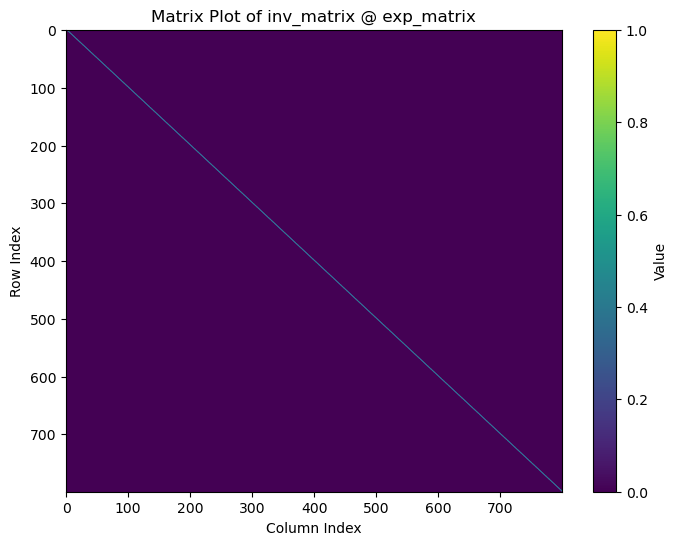

In [51]:
import matplotlib.pyplot as plt

# Compute the matrix
result_matrix = inv_matrix @ exp_matrix

# Plot the matrix
plt.figure(figsize=(8, 6))
plt.imshow(result_matrix.cpu().numpy(), cmap='viridis', aspect='auto')
plt.colorbar(label='Value')
plt.title('Matrix Plot of inv_matrix @ exp_matrix')
plt.xlabel('Column Index')
plt.ylabel('Row Index')
plt.show()